# Gradient Decent Theory

h( x ) = w * x + b   
here, b is the bias or intercept
x represents the feature vector
w represents the weight vector or slope

Loss Fucntion = 1/n summation (actual y - predicted y)
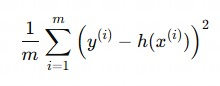

## we have to minimize this loss function by choosing the best values of slope(w) and intercept(b)

# Pseudo Code

Gradient descent:
Pseudo Code:

Start with some w
Keep changing w to reduce J( w ) [Loss Function] until we hopefully end up at a minimum.
Algorithm:

repeat until convergence
 {  tmpi = wi - alpha * dwi        wi = tmpi              }   **OR**

 Updating Parameter: { **m**(new) = **m** (old) - learning rate (derivative function with respect to m or with respect to b

 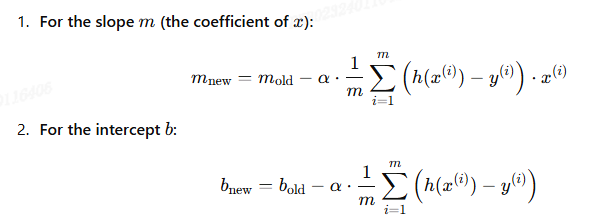


where alpha is the learning rate.

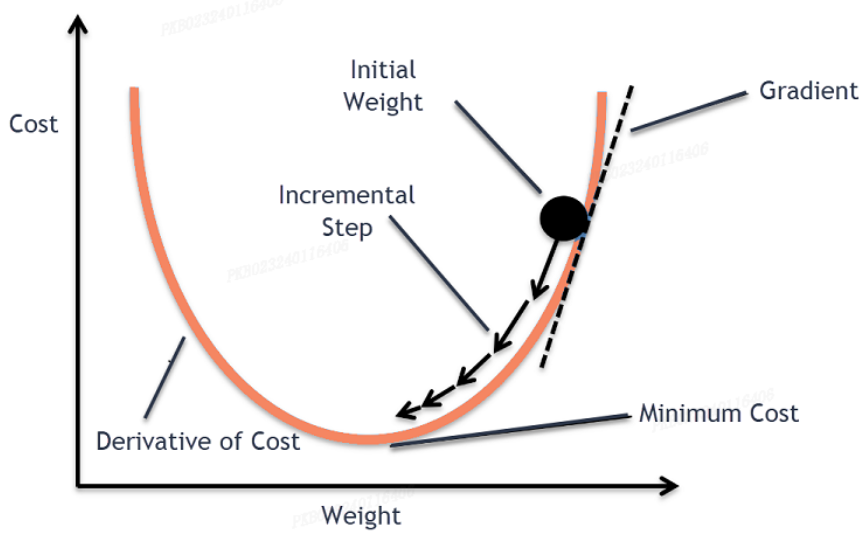

# Let's Begin with Implementation

In [1]:
# Importing Required Libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
pd.set_option('display.max_columns',100)     # to display max 100 columns not as per the defualt set in the pandas
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 12              # to set the font size for text elements
plt.rcParams['figure.figsize'] = (22, 5)    # to set the figure size for each plot or figure that we will use
plt.rcParams['figure.dpi'] = 100

import sqlite3
from sklearn.metrics import r2_score, roc_curve, auc           #Evaluation metrics
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

from urllib.request import urlretrieve         #to load the dataset from the provided url efficiently

In [2]:
medical_dataset_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

# storing the data into dataframe
medical_df = pd.read_csv(medical_dataset_url)
medical_df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [3]:
# checking the shape of the dataset
medical_df.shape

(1338, 7)

In [4]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Exploratory Data Analysis (EDA)

In [6]:
# Creating sql database
conn = sqlite3.connect('medical_database.db')

# Creating Dataframe into table
medical_df.to_sql('medical_data', conn, if_exists='replace', index=False)

1338

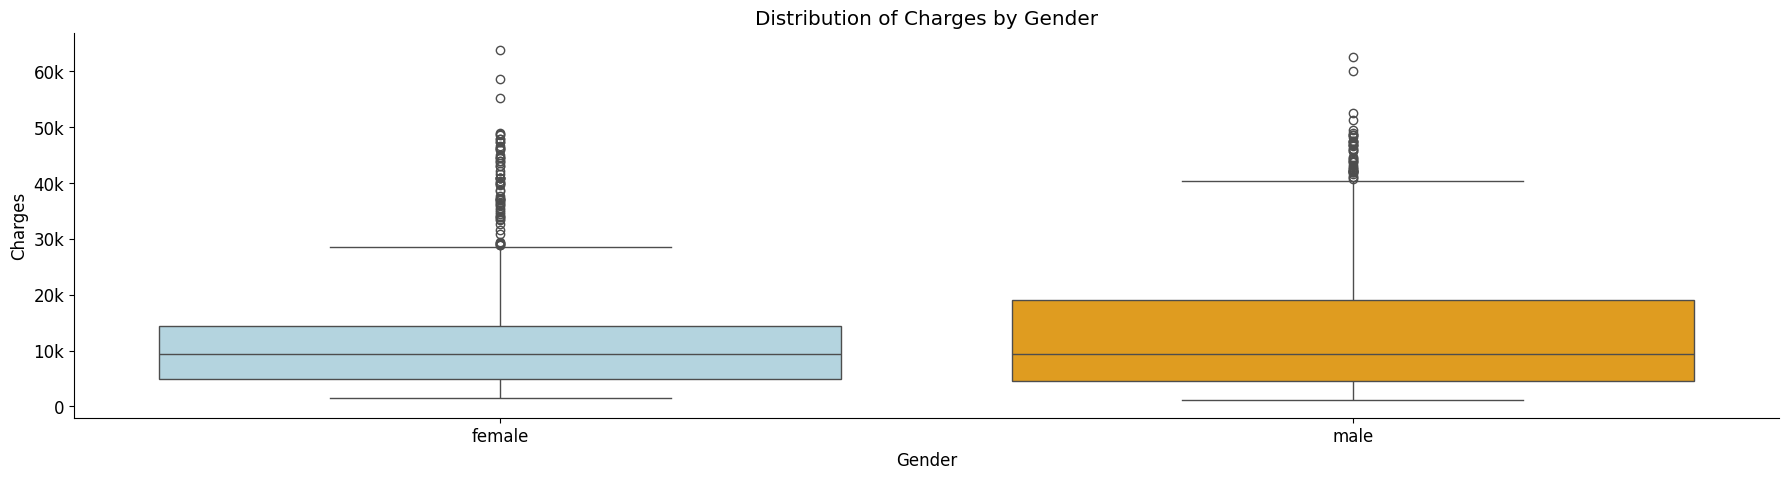

<Figure size 800x500 with 0 Axes>

In [7]:
custom_palette = {'female':'lightblue', 'male':'Orange'}
sns.boxplot(medical_df, x='sex', y='charges', palette=custom_palette)     # After running this snipper we would know that it shows simple boxplot, so we need to do formating
yticks = plt.gca().get_yticks()               #approaching or getting y ticks or y labels
y_labels = [f"{round(i/1000)}k" if i != 0 else '0' for i in yticks]          #formating y labels like 1000 to 1k
plt.gca().set_yticklabels(y_labels)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title('Distribution of Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.figure(figsize=(8,5))
plt.show()

From the above plot we can see that males are about to spend more insurance charges then female

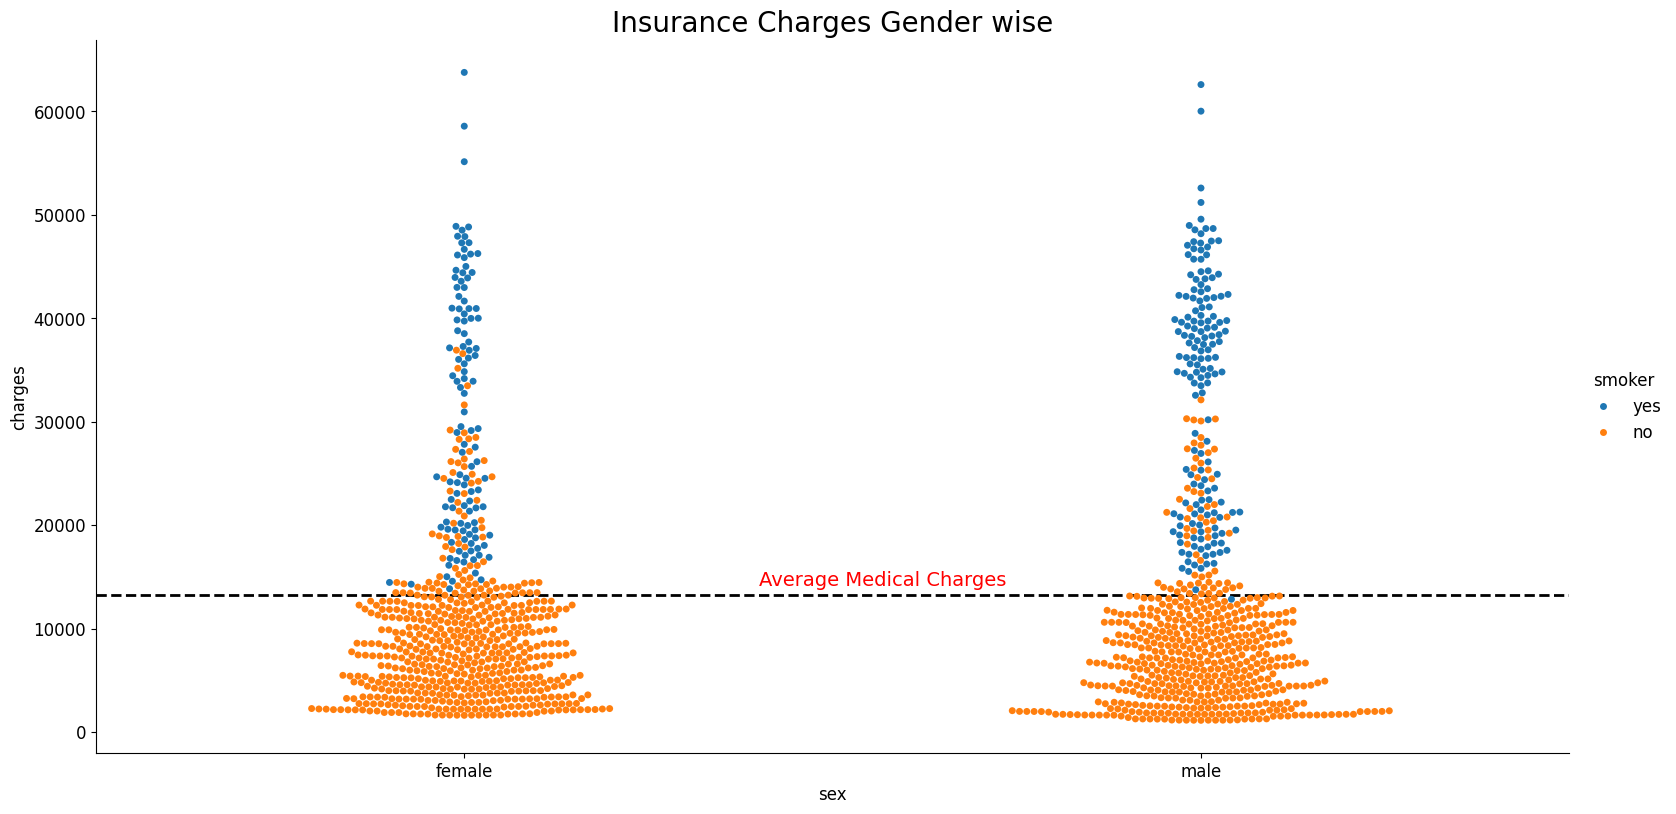

In [8]:
sns.catplot(data=medical_df, x = 'sex', y = 'charges', kind = 'swarm', hue ='smoker', aspect = 2, height = 8)

# plotting mean line of charges in graph
plt.axhline(medical_df['charges'].mean(), linestyle = '--', lw=2,color='black')
plt.annotate(f'Average Medical Charges', (.4, medical_df['charges'].mean()+900), fontsize=14, color='red')
plt.title('Insurance Charges Gender wise', fontsize=20)
plt.show()

# plt.axhline(medical_df['charges'].mean(), linestyle='--', lw=2, zorder=1, color='black')

From the plot above we can see that male smokers are likely to spend more on insurance

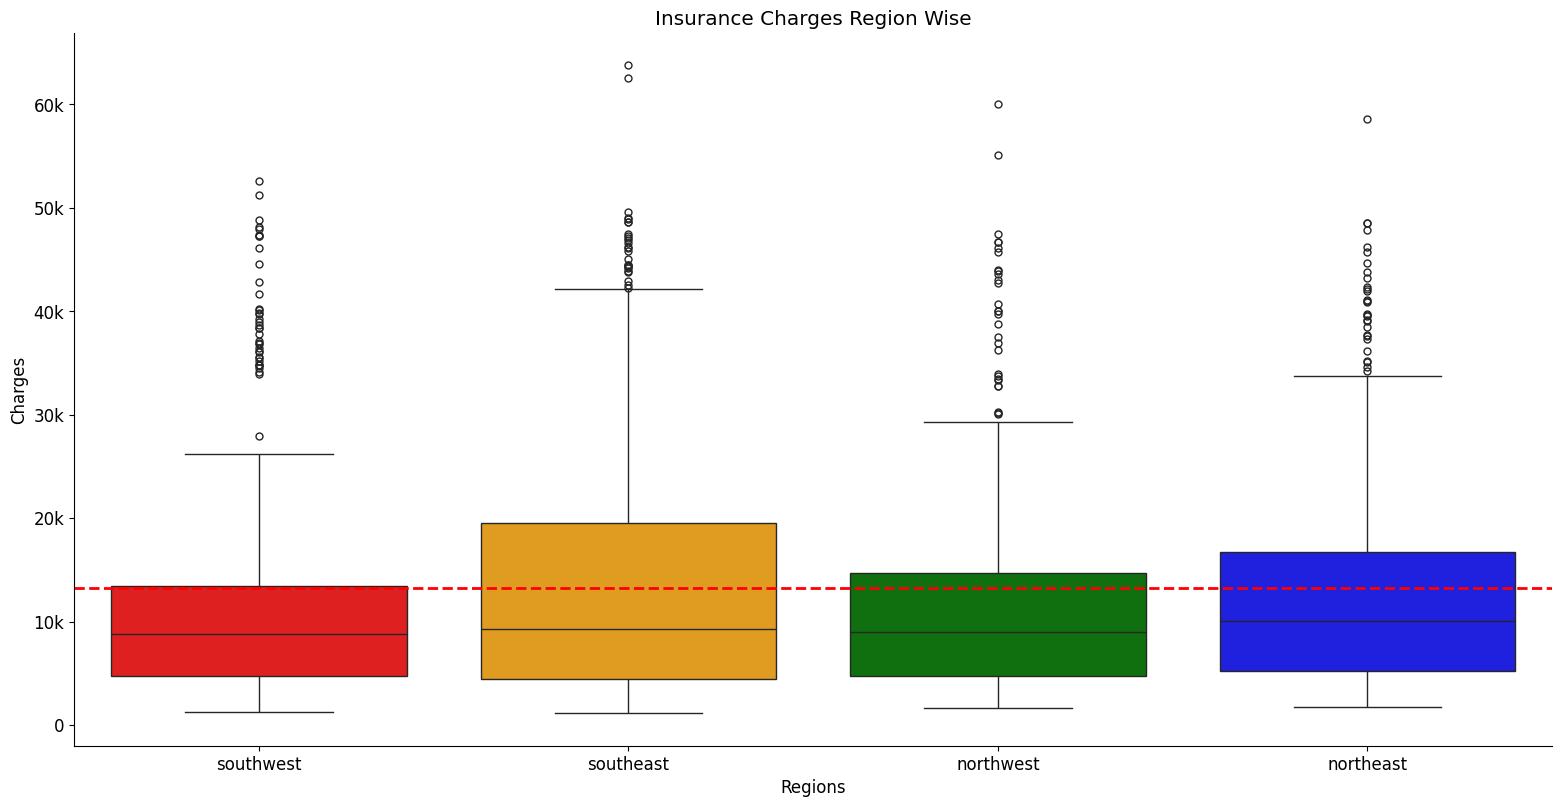

In [9]:
custom_palette = ['red', 'orange','green', 'blue']
sns.catplot(data=medical_df,x='region', y='charges', kind='box', aspect=2, height=8, palette=custom_palette)
yticks=plt.gca().get_yticks()
y_labels=[f'{round(i/1000)}k' if i!=0 else '0' for i in yticks]
plt.gca().set_yticklabels(y_labels)
plt.axhline(medical_df['charges'].mean(), linestyle='--',lw=2, color='red')
plt.title('Insurance Charges Region Wise')
plt.xlabel('Regions')
plt.ylabel('Charges')
plt.show()

Insurance charges spend by more in southeast region as compare to northwest or southwest

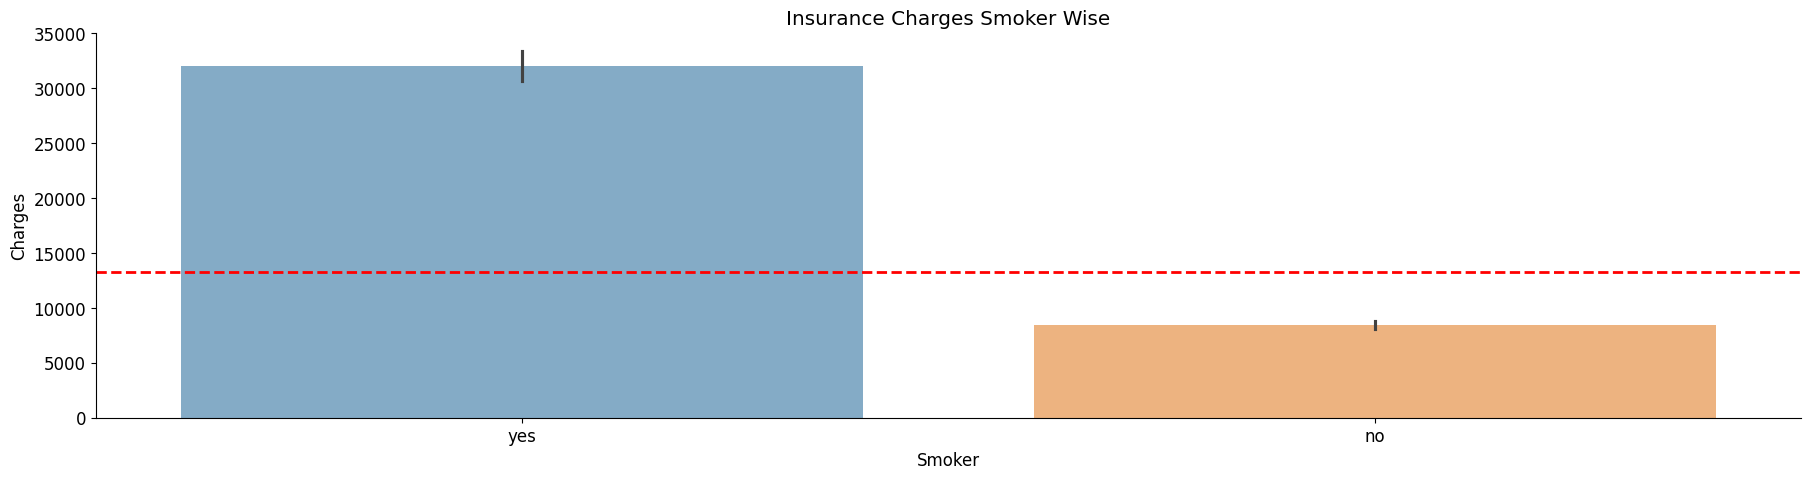

In [10]:
sns.barplot(data=medical_df, x='smoker', y='charges', hue='smoker',alpha=0.6, dodge=False)
plt.axhline(medical_df['charges'].mean(), linestyle='--', lw=2, color='red')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title('Insurance Charges Smoker Wise')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

Smokers paying more insurance charges then non smokers

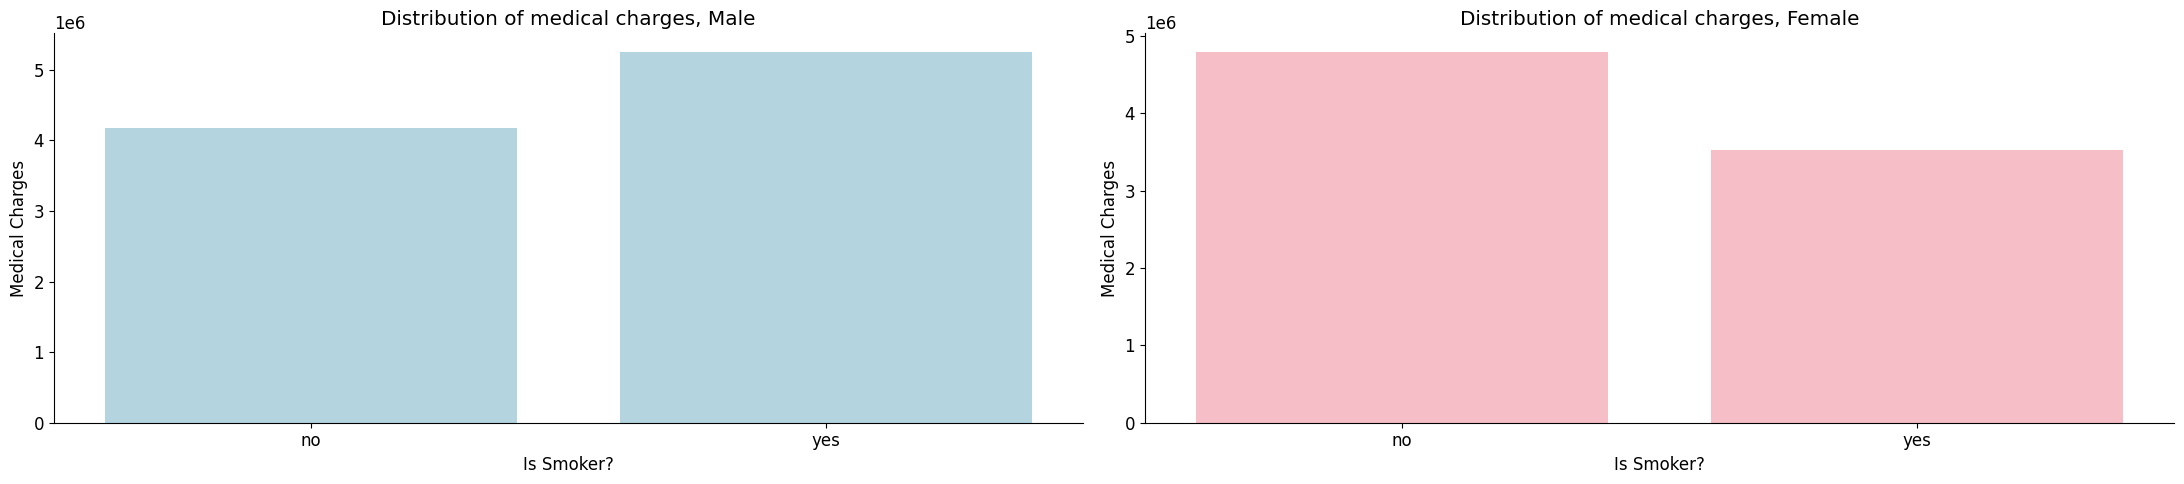

In [11]:
# Query to get data from our database that we created above as medical_data
query = """
select sex, smoker, round(sum(charges), 2) as medical_charges
from medical_data
group by sex, smoker
"""
temp = pd.read_sql(query,conn)             #loading data from sql to pandas dataframe
male_df=temp[temp['sex']=='male']          #filtering of sex column to male only
female_df=temp[temp['sex']=='female']      #filtering of sex column to female only


# Creating subplots of male and female with respect to the smokers or not
plt.subplot(1,2,1)                                                                      #first subplot
sns.barplot(x=male_df['smoker'], y=male_df['medical_charges'], color='lightblue')
plt.xlabel('Is Smoker?')
plt.ylabel('Medical Charges')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title('Distribution of medical charges, Male')

plt.subplot(1,2,2)                                    #second subplot
sns.barplot(x=female_df['smoker'],y=female_df['medical_charges'], color='lightpink')
plt.xlabel('Is Smoker?')
plt.ylabel('Medical Charges')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title('Distribution of medical charges, Female')

plt.tight_layout()             #adjusting layout
plt.show()

From the above chart we can see that Male who smoke pay high charges while female ho dont smoke pay high charges

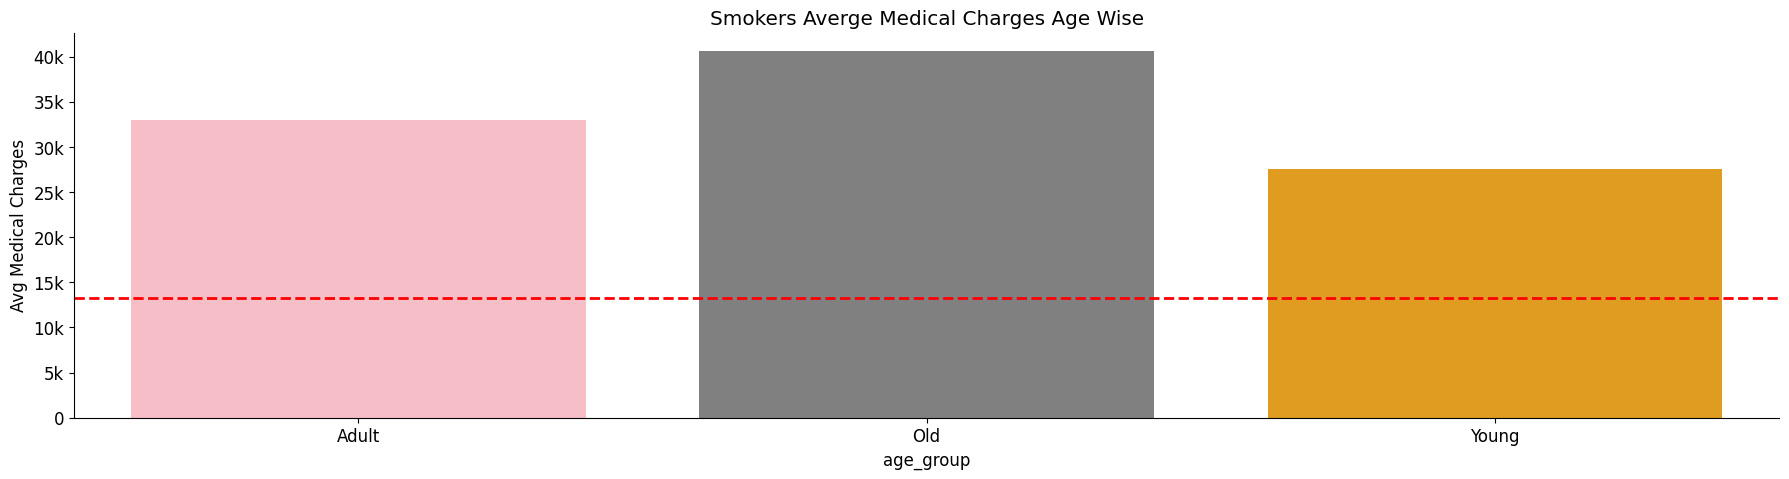

In [12]:
query = """
select
  case
    when age<30 then 'Young'
    when age<60 then 'Adult'
    else 'Old'
  end as age_group,
  round(avg(charges),2) as avg_charges

From
  medical_data
where smoker =='yes'
group by
  case
    when age<30 then 'Young'
    when age<60 then 'Adult'
    else 'Old'
  end;
"""

temp = pd.read_sql(query, conn)
custom_palette = ['lightpink','grey','orange']

sns.barplot(data=temp, x='age_group', y='avg_charges', hue='age_group', dodge=False, palette=custom_palette)
yticks=plt.gca().get_yticks()
y_labels = [f"{round(i/1000)}k" if i != 0 else "0" for i in yticks]
plt.gca().set_yticklabels(y_labels)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axhline(medical_df['charges'].mean(),linestyle='--', lw=2, zorder=1, color='red')
# plt.annotate(f'Avg Medical Charges', (.5, medical_df['charges'].mean()+1000), fontsize=12, color='darkred')
plt.title('Smokers Averge Medical Charges Age Wise')
plt.ylabel('Avg Medical Charges')
plt.show()

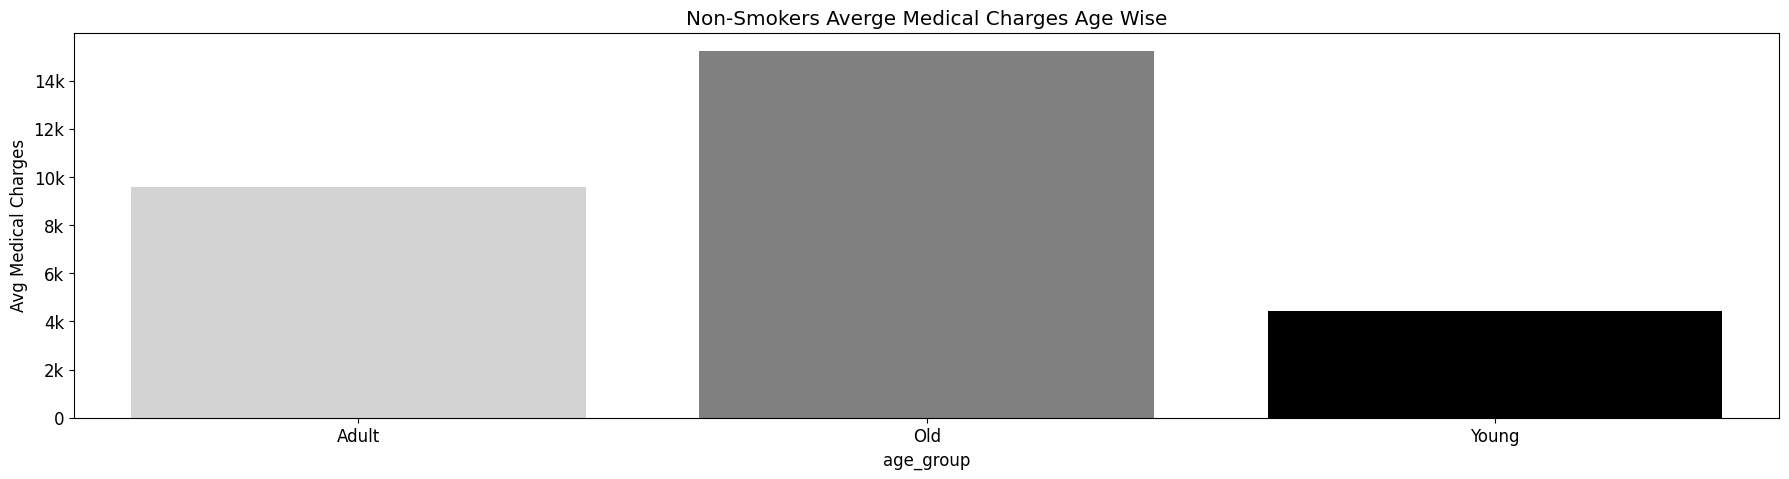

In [13]:
query = """
select
  case
    when age<30 then 'Young'
    when age<60 then 'Adult'
    else 'Old'
  end as age_group,
  round(avg(charges),2) as avg_charges

From
  medical_data
where smoker =='no'
group by
  case
    when age<30 then 'Young'
    when age<60 then 'Adult'
    else 'Old'
  end;
"""

temp = pd.read_sql(query,conn)
custom_palette = ['lightgrey','grey','black']

sns.barplot(data=temp, x='age_group', y = 'avg_charges', hue='age_group', dodge = False, palette=custom_palette)
yticks = plt.gca().get_yticks()
y_labels = [f"{round(i/1000)}k" if i != 0 else "0" for i in yticks]
plt.gca().set_yticklabels(y_labels)
plt.title('Non-Smokers Averge Medical Charges Age Wise')
plt.ylabel('Avg Medical Charges')
plt.show()


Adults and young who smoke spend more on inusrance charges as compare to the non- smoker Adults and young

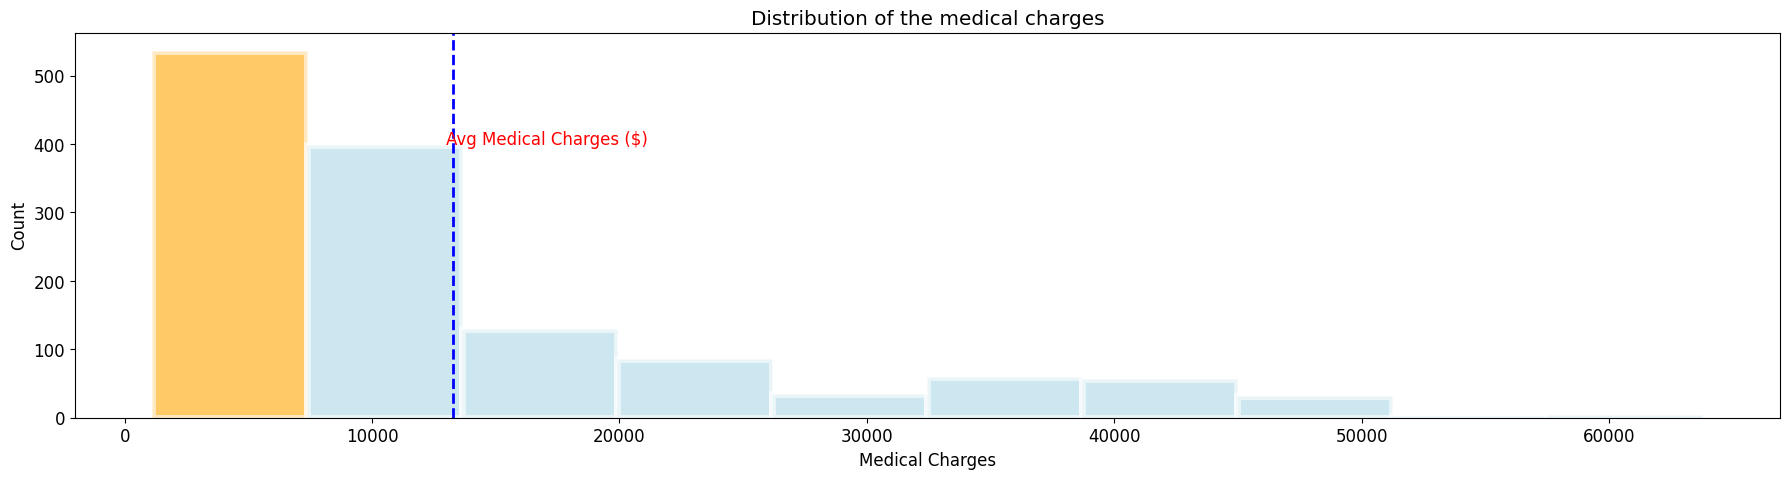

In [14]:
fig , ax = plt.subplots()
N, bins, patches = ax.hist(np.array(medical_df.charges), edgecolor = 'white', color = 'lightblue', linewidth = 5, alpha=0.6)

for i in range(0,1):
  patches[i].set_facecolor('orange')
  plt.title('Distribution of the medical charges')
  plt.axvline(medical_df['charges'].mean(), linestyle='--', lw=2, color = 'blue', zorder = 1)
  plt.annotate(f"Avg Medical Charges ($)", (13000,400),color = 'red', fontsize = 12)
  plt.xlabel('Medical Charges')
  plt.ylabel('Count')
  plt.show()

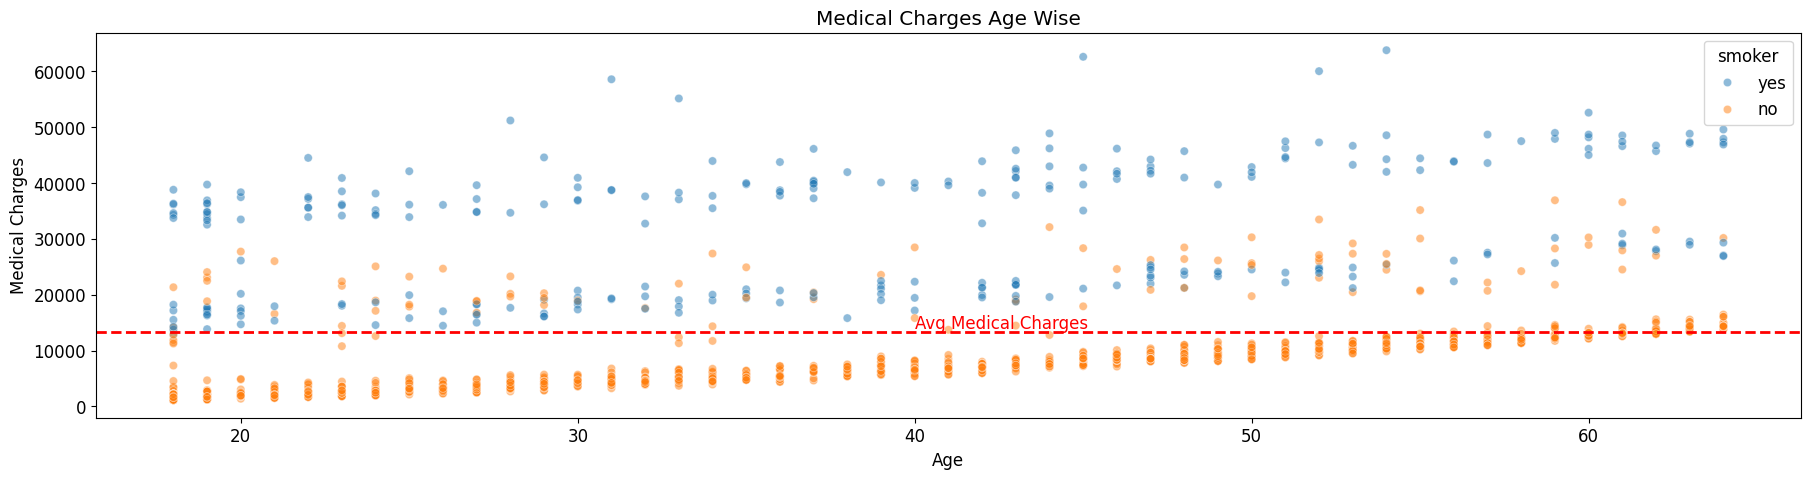

In [15]:
sns.scatterplot(y=medical_df['charges'], x= medical_df['age'], hue = medical_df['smoker'], alpha = 0.5)
plt.axhline(medical_df['charges'].mean(),linestyle ='--', lw = 2, zorder = 1, color = 'red')
plt.annotate(f"Avg Medical Charges", (40,13900), color='red', fontsize = 12)
plt.title('Medical Charges Age Wise')
plt.xlabel('Age')
plt.ylabel('Medical Charges')
plt.show()

Smoker are likely to spend more on insurance charges as compare to non-smoker

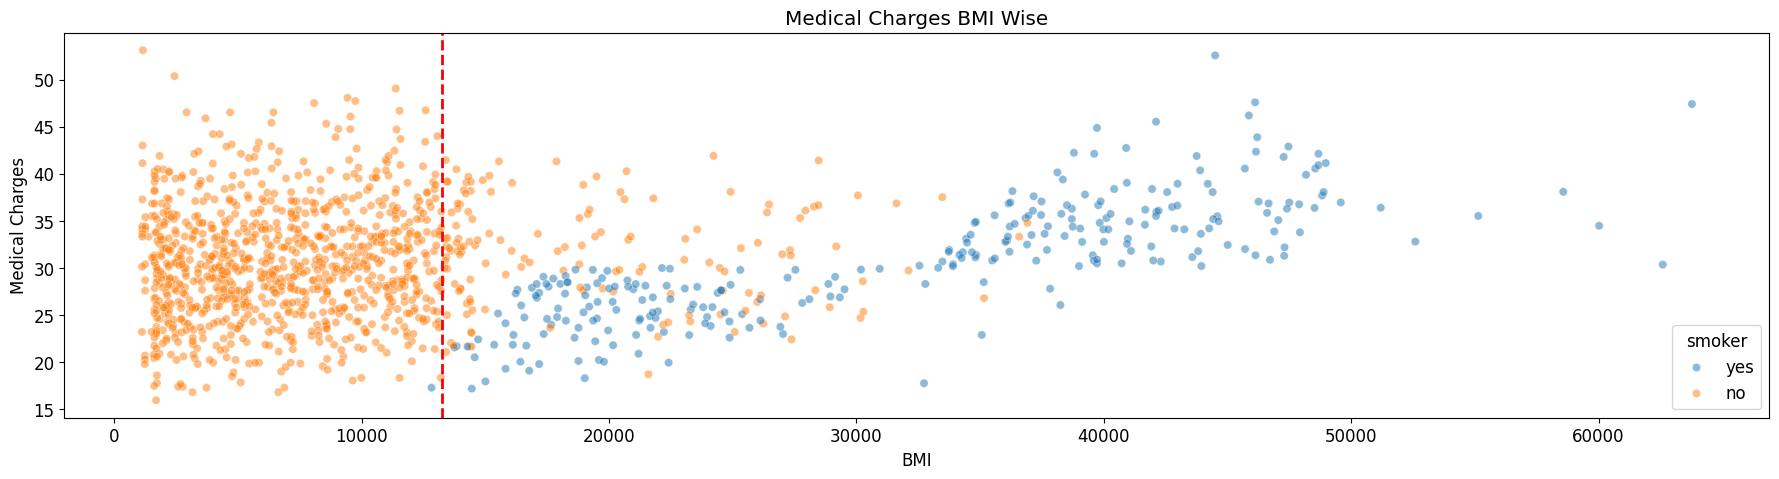

In [16]:
sns.scatterplot(y= medical_df['bmi'], x= medical_df['charges'], hue = medical_df['smoker'], alpha=0.5)
plt.axvline(medical_df['charges'].mean(),linestyle='--', lw=2, zorder=1, color='red')
plt.annotate(f'Avg Medical Charges', (13900,400), color='red', fontsize=12)
plt.title('Medical Charges BMI Wise')
plt.xlabel('BMI')
plt.ylabel('Medical Charges')
plt.show()

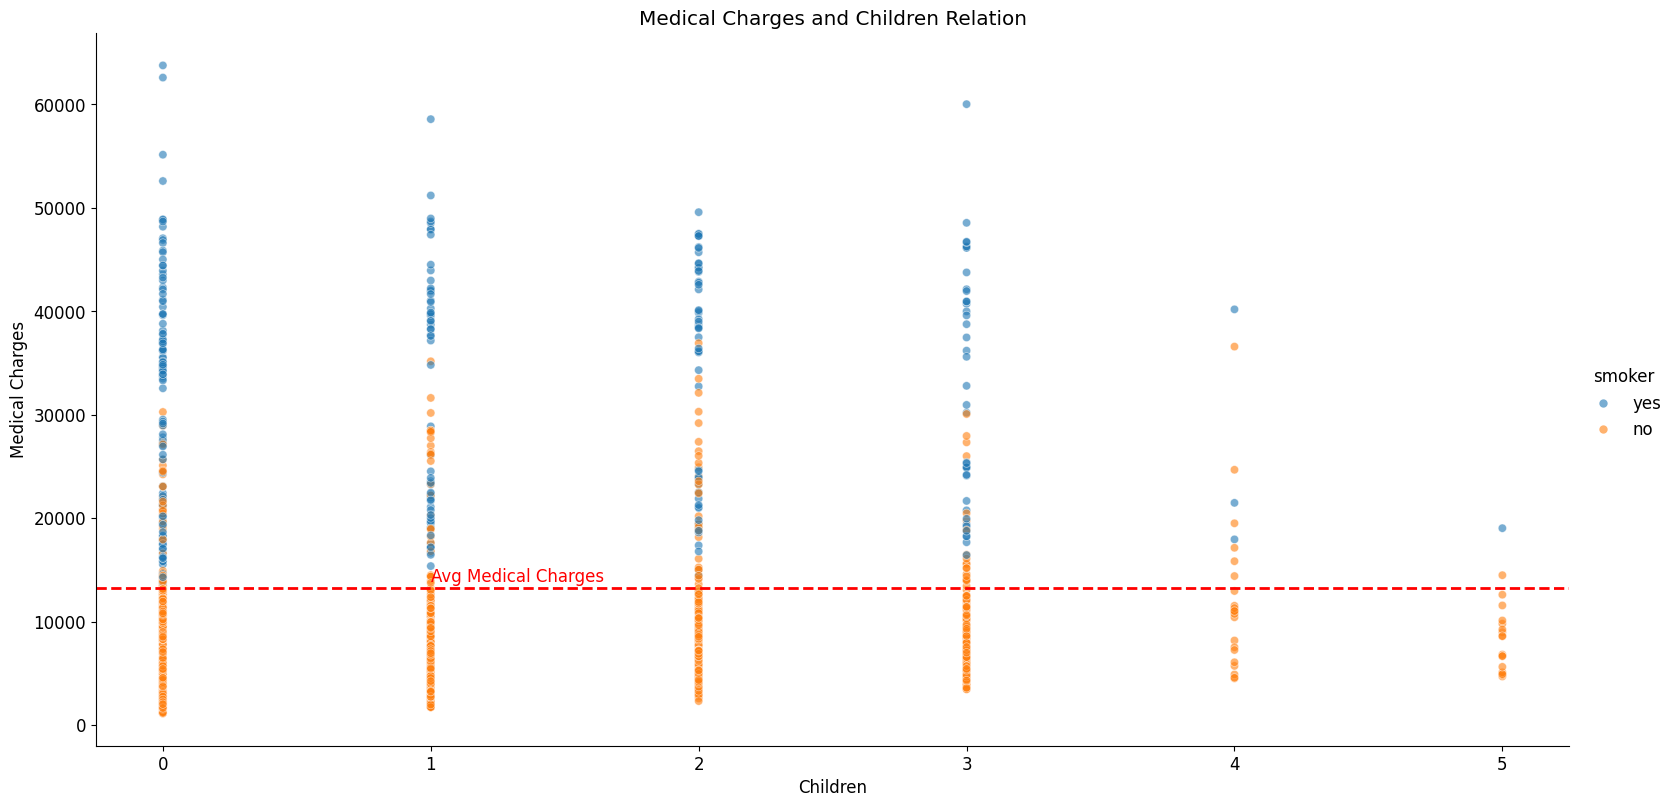

In [17]:
sns.relplot(data=medical_df, x= medical_df['children'], y=medical_df['charges'], hue=medical_df['smoker'],alpha=0.6, aspect=2, height=8)
plt.axhline(medical_df['charges'].mean(),linestyle='--',lw=2, color='red')
plt.annotate(f'Avg Medical Charges', (1,13900),color='red', fontsize=12)
plt.title('Medical Charges and Children Relation')
plt.xlabel('Children')
plt.ylabel('Medical Charges')
plt.show()

people with 0, 1 and 3 childrens are more likely to spend more insurance charges

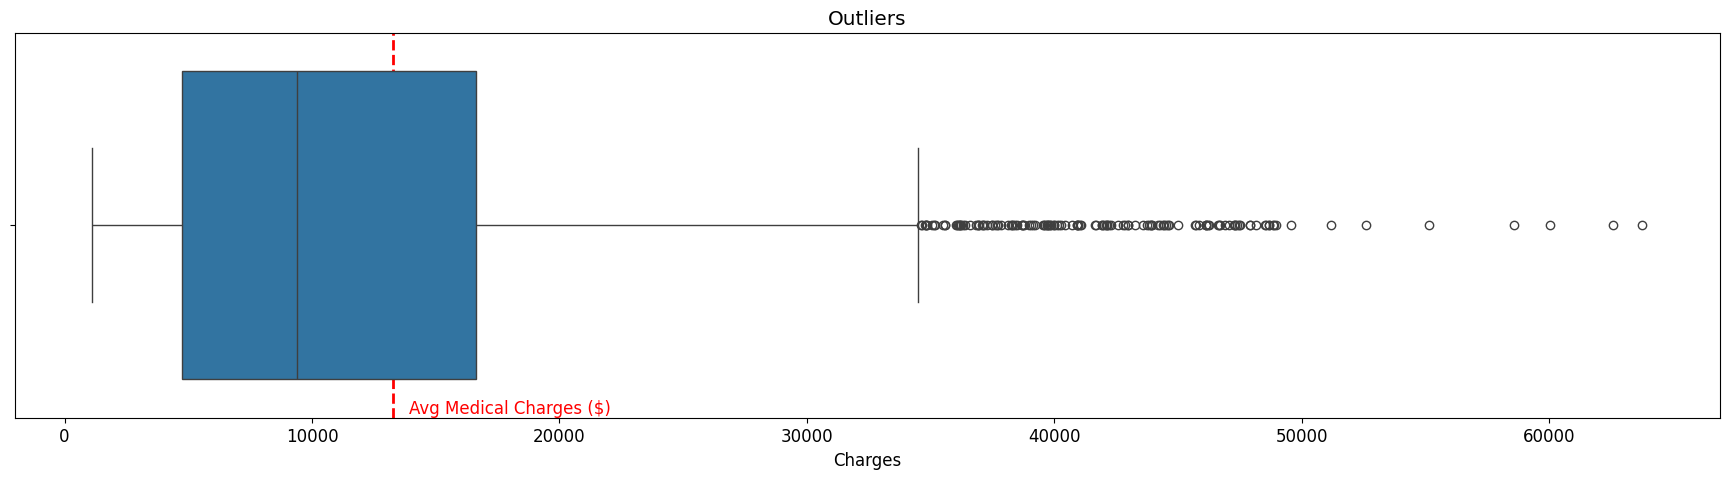

In [18]:
sns.boxplot(x=medical_df['charges'])
plt.axvline(medical_df['charges'].mean(),color= 'red', linestyle='--', zorder=1,lw=2 )
plt.annotate(f'Avg Medical Charges ($)',(13900,0.49), color='red', fontsize=12)
plt.title('Outliers')
plt.xlabel('Charges')
plt.show()

# Data Pre-Processing

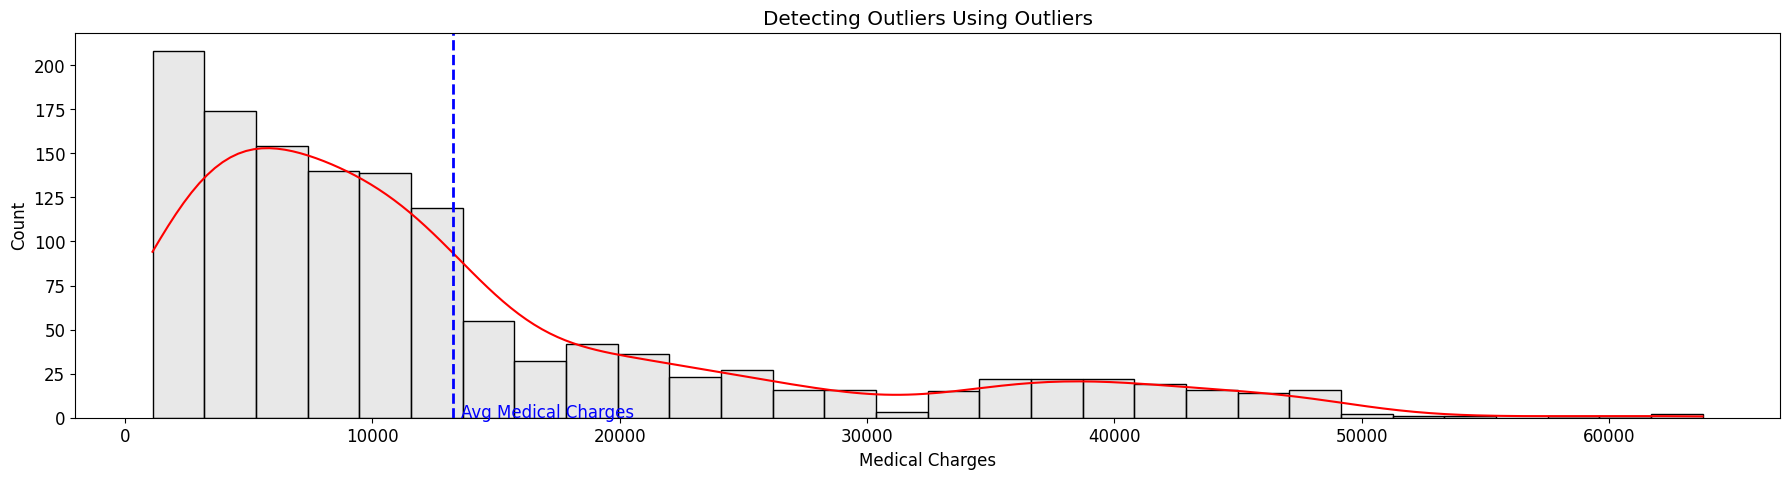

In [19]:
ax=sns.histplot(medical_df['charges'], kde=True, color='lightgrey')
ax.lines[0].set_color('red')
plt.axvline(medical_df['charges'].mean(), linestyle='--', lw=2, color='blue')
plt.annotate(f'Avg Medical Charges', (13600, 0.40), color='blue',fontsize=12)
plt.title('Detecting Outliers Using Outliers')
plt.xlabel('Medical Charges')
plt.ylabel('Count')
plt.show()

In [20]:
data = sorted(medical_df['charges'].values)           # extracting values from the medical_df dataframe and sorted them

data_mean = np.mean(data)            #calculating mean of the data
data_std = np.std(data)              #calculating standard deviation of the data

cut_off = data_std*3             #calculating cut_off value which is 3 times of the standard deviation

lower = data_mean-cut_off        #calculating lower bound and upper bound to identify potential outliers
upper = data_mean+cut_off

print('Cut_off = ', round(cut_off, 3))
print('Lower Bound = ', round(lower,3))
print('Upper Bound = ', round(upper,3))

Cut_off =  36316.455
Lower Bound =  -23046.033
Upper Bound =  49586.877


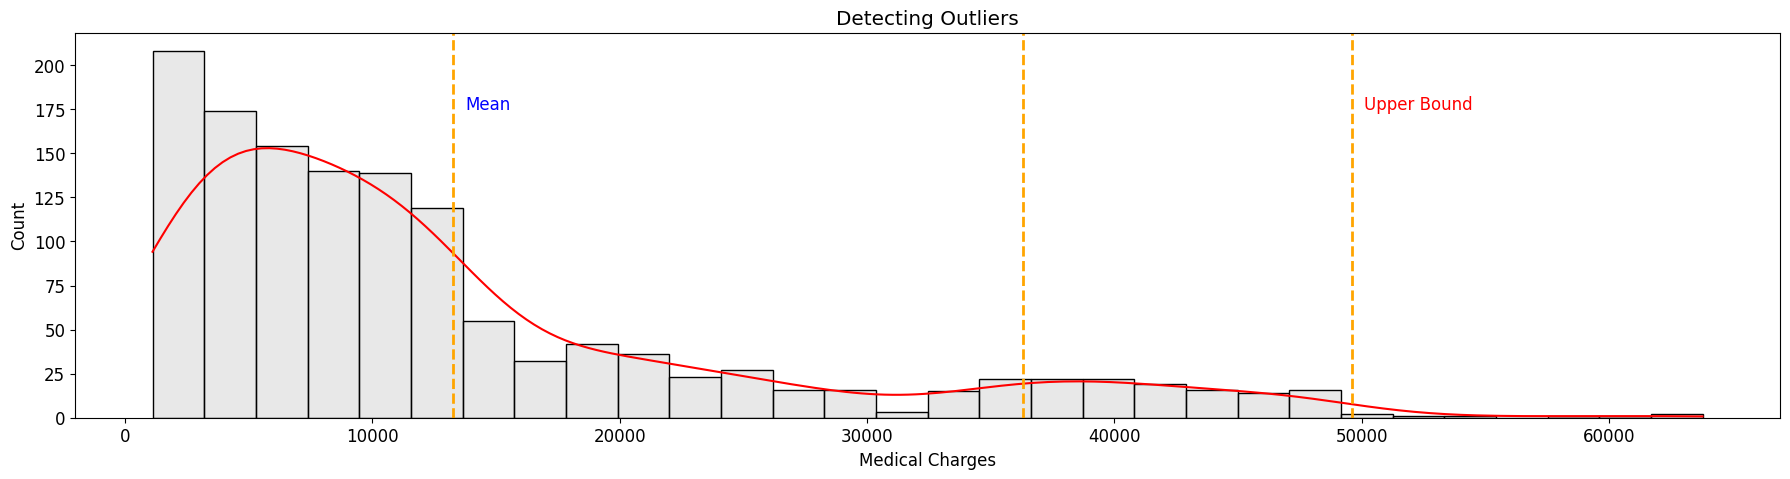

In [21]:
ax=sns.histplot(medical_df['charges'],kde=True, color='lightgrey')
plt.axvline(data_mean, linestyle='--', lw=2, color='orange')
plt.annotate(f'Mean', (data_mean+500, 175), fontsize=12, color='blue')
ax.lines[0].set_color('red')

plt.axvline(cut_off, linestyle='--', lw=2, color='orange')
plt.annotate(f'Lower Bound', (lower+500, 175), fontsize=12, color='red')

plt.axvline(upper, linestyle='--', lw=2, color='orange')
plt.annotate(f'Upper Bound', (upper+500, 175), fontsize=12, color='red')

plt.title('Detecting Outliers')
plt.xlabel('Medical Charges')
plt.ylabel('Count')
plt.show()

In [22]:
medical_df = medical_df[medical_df['charges'] < upper]
medical_df = medical_df[medical_df['charges'] > lower]

print('Shape of data frame after removing Outliers', medical_df.shape)

Shape of data frame after removing Outliers (1331, 7)


In [23]:
# Making copy of the data frame
df = medical_df.copy()

# One Hot Encoding

In [24]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_cols = df.select_dtypes(include='object').columns
encoder.fit(df[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [25]:
onehot = encoder.transform(df[categorical_cols])
encoder.categories_

[array(['female', 'male'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [26]:
encoded_cols = [['female', 'male', 'smokerno','smokeryes', 'northeast', 'northwest', 'southeast', 'southwest']]
df[['female', 'male', 'smokerno', 'smokeryes', 'northeast', 'northwest', 'southeast', 'southwest']] = onehot
df.drop(categorical_cols, axis=1, inplace=True)

In [27]:
df.head()

,age,bmi,children,charges,female,male,smokerno,smokeryes,northeast,northwest,southeast,southwest
0,19,27.900,0,16884.92400,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,18,33.770,1,1725.55230,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [28]:
# Scaling
scaler = MinMaxScaler()

y = df['charges'].values

x = df.drop('charges', axis=1).values              #Droping charges column from the dataframe to create feature matrix

print('Shape of the independent variables is: ', x.shape)
print('shape of targert variable is: ', y.shape)

Shape of the independent variables is:  (1331, 11)
shape of targert variable is:  (1331,)


# Derivation of the Equation




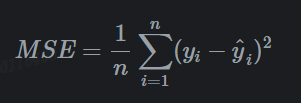

We will do the partial differentiation of this matrix with respect to m and b as well after putting the values y = mx+b in the above equation in the place of y-hat.
Our final equations after differentiation will look like this

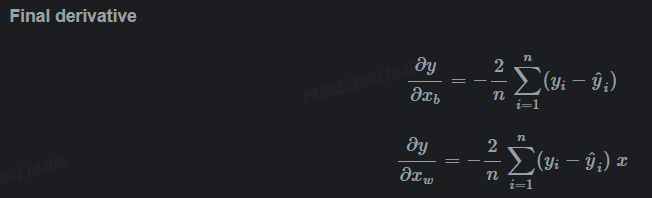

Updating parameters Rule that we defined before

 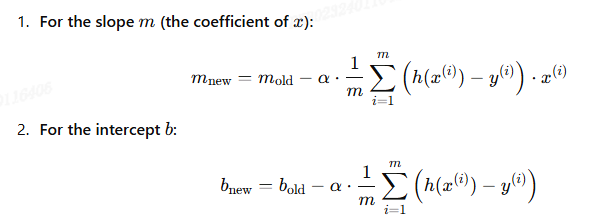

# Building Model and Training

In [29]:
# Function for early stopping criterea by comparing consecutive losses
def early_stopping(loss):
  for i in range (1, len(loss)):
    yield (loss[i-1], loss[i])

# Function for determining number of batches based on the size of the dataset
def batch_size(batchsize, X):
  batches = round(X.shape[0] // batchsize)
  return batches

# Gradient decent function for Linear Regression
def gradient_decent(X_train, y_train, m, b):
  yhat = np.dot(X_train,m)+b                             # y = mx + b

# Mean Square Error
  MSE = np.sum((y_train - yhat)**2)/N

# R square Score
  r_squared = r2_score(y_train, yhat)


# Final derived equations calculations

  partial_derivative_b = (-2/N) * np.sum(y_train - yhat)                #First of equation of final derivative that is given above
  partial_derivative_m = -(2/N) * np.dot((y_train - yhat), X_train)     # second equation of final derivative that is given above


# Updating parameters m and b using the above two equations

  m = m - (learning_rate * partial_derivative_m)
  b = b - (learning_rate * partial_derivative_b)

  return m, b, MSE, r_squared

In [30]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 50)

In [31]:
# Scanling the values
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

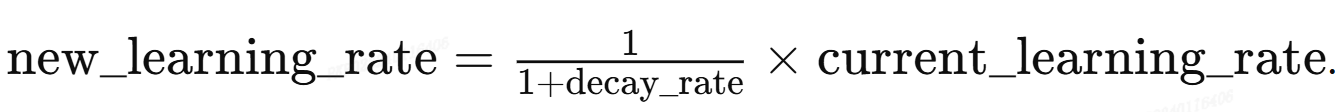

In [32]:
# setting and fixing seed to generte same randmon numbers each time we run the code
np.random.seed(42)

# Total number of data points
N = x.shape[0]

# Setting initial learning rate, decay rate and other variables
learning_rate = 0.02
decay_rate = 0.01
LR = []                #list to store learning rate
Validationloss = []    #list to store validation loss
Trainingloss = []        #list to store training loss
batchsize = 30
R_squared_train =[]
R_Squared_test = []


# Initializing intercept and slope
Intercept = []    #list to store intercpet b
Slope = []        #list to store slope m
m = np.ones(x.shape[1])          #initializing value for m and b
b = 1
print('Initial value of m and b are ', m,',' ,b)


# calculating number of batches
batches = batch_size(batchsize, x)

num_itterations = 2000

for i in range (num_itterations):                #Loop for multiple itterations
  itteration = i

  for j in range(batches):               #Loop for batches
    if i == 0:                           #First Itteration, initalizing values
      if j % batchsize == 0:             #This will be implemented for each batchsize
        learning_rate = learning_rate    #Initailizing Learining rate
        np.random.seed(42)
        np.random.shuffle([scaled_X_train,y_train])
        m, b, MSE, r_squared = gradient_decent(scaled_X_train,y_train,m,b)
        m_test, b_test, MSE_test, r_squared_test = gradient_decent(scaled_X_test, y_test,m,b)
      else:
        m = m
        b = b
    else:
      if j % batchsize == 0:
        learning_rate = [(1/ (1+decay_rate))* learning_rate for j in range(batches)][0]
        np.random.seed(0)
        np.random.shuffle([scaled_X_train,y_train])
        m, b, MSE, r_squared = gradient_decent(scaled_X_train,y_train,m,b)
        m_test, b_test, MSE_test, r_squared_test = gradient_decent(scaled_X_test, y_test,m,b)
      else:
        m = m
        b = b
  #Storing values for anlaysis and tracking
  Intercept.append(b)
  Slope.append(m)
  LR.append(learning_rate)
  Trainingloss.append(MSE)
  Validationloss.append(MSE_test)
  R_squared_train.append(r_squared)
  R_Squared_test.append(r_squared_test)

  #printing progress every 100 itterations
  if i % 100 == 0:
    print(f'Itteration: {i}/{num_itterations} [-----] Loss: {MSE:.2e} Validation_Loss: {MSE_test:2e} r_squared: {round(r_squared,4)} r_squared_test: {round(r_squared_test,4)}')


  # Early Stopping Phenomena
  for prev,curr in early_stopping(Validationloss):
    if prev - curr < 1e-6:
      print(f'\n Early stopping at Itteration: {i} Validation_Loss: {np.around(MSE_test,5)} Validation_r_squared: {np.around(r_squared_test,5)} ')
      break
  else:
    continue         #if early stopping condition not occur then continue to itterate
  break              #if the early stopping condition occured the after breaking the innero loop also break the outer loop means this will only executed if the inner loop is breaked


# Printing the Final Results
print(f'\n The Final Values of m and b are: ', m, b)



Initial value of m and b are  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] , 1
Itteration: 0/2000 [-----] Loss: 2.21e+08 Validation_Loss: 5.201340e+07 r_squared: -1.0383 r_squared_test: -0.8267
Itteration: 100/2000 [-----] Loss: 4.85e+07 Validation_Loss: 1.243413e+07 r_squared: 0.5518 r_squared_test: 0.5633
Itteration: 200/2000 [-----] Loss: 4.50e+07 Validation_Loss: 1.146930e+07 r_squared: 0.5843 r_squared_test: 0.5972
Itteration: 300/2000 [-----] Loss: 4.46e+07 Validation_Loss: 1.135233e+07 r_squared: 0.5882 r_squared_test: 0.6013
Itteration: 400/2000 [-----] Loss: 4.45e+07 Validation_Loss: 1.133659e+07 r_squared: 0.5888 r_squared_test: 0.6019
Itteration: 500/2000 [-----] Loss: 4.45e+07 Validation_Loss: 1.133445e+07 r_squared: 0.5888 r_squared_test: 0.6019
Itteration: 600/2000 [-----] Loss: 4.45e+07 Validation_Loss: 1.133415e+07 r_squared: 0.5888 r_squared_test: 0.6019
Itteration: 700/2000 [-----] Loss: 4.45e+07 Validation_Loss: 1.133411e+07 r_squared: 0.5888 r_squared_test: 0.6019
Itteration:

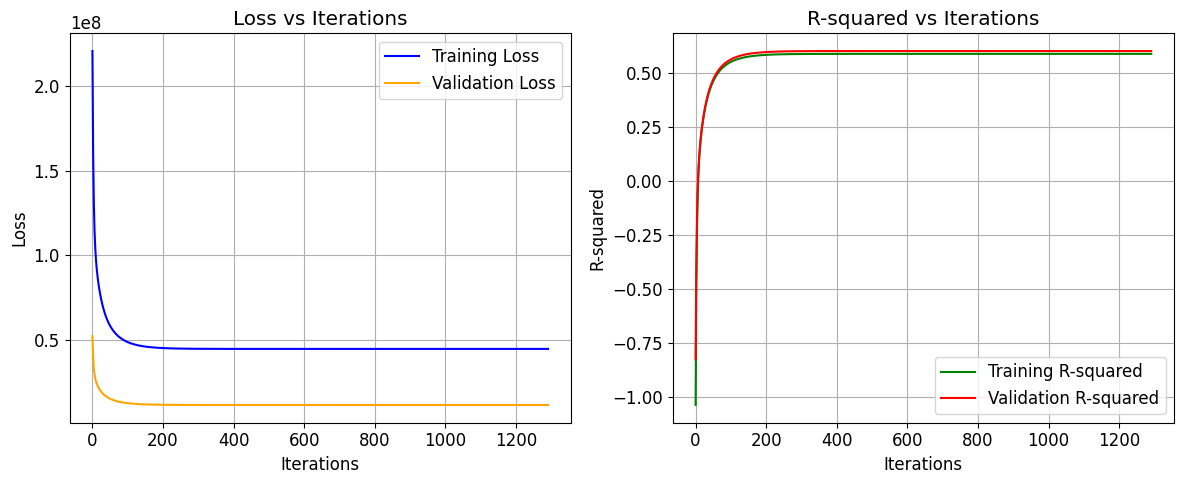

In [33]:
iterations = range(len(Trainingloss))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(iterations, Trainingloss, label='Training Loss', color='blue')
plt.plot(iterations, Validationloss, label='Validation Loss', color='orange')
plt.title('Loss vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(iterations,R_squared_train, label='Training R-squared', color='green')
plt.plot(iterations,R_Squared_test, label='Validation R-squared', color='red')
plt.title('R-squared vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('R-squared')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

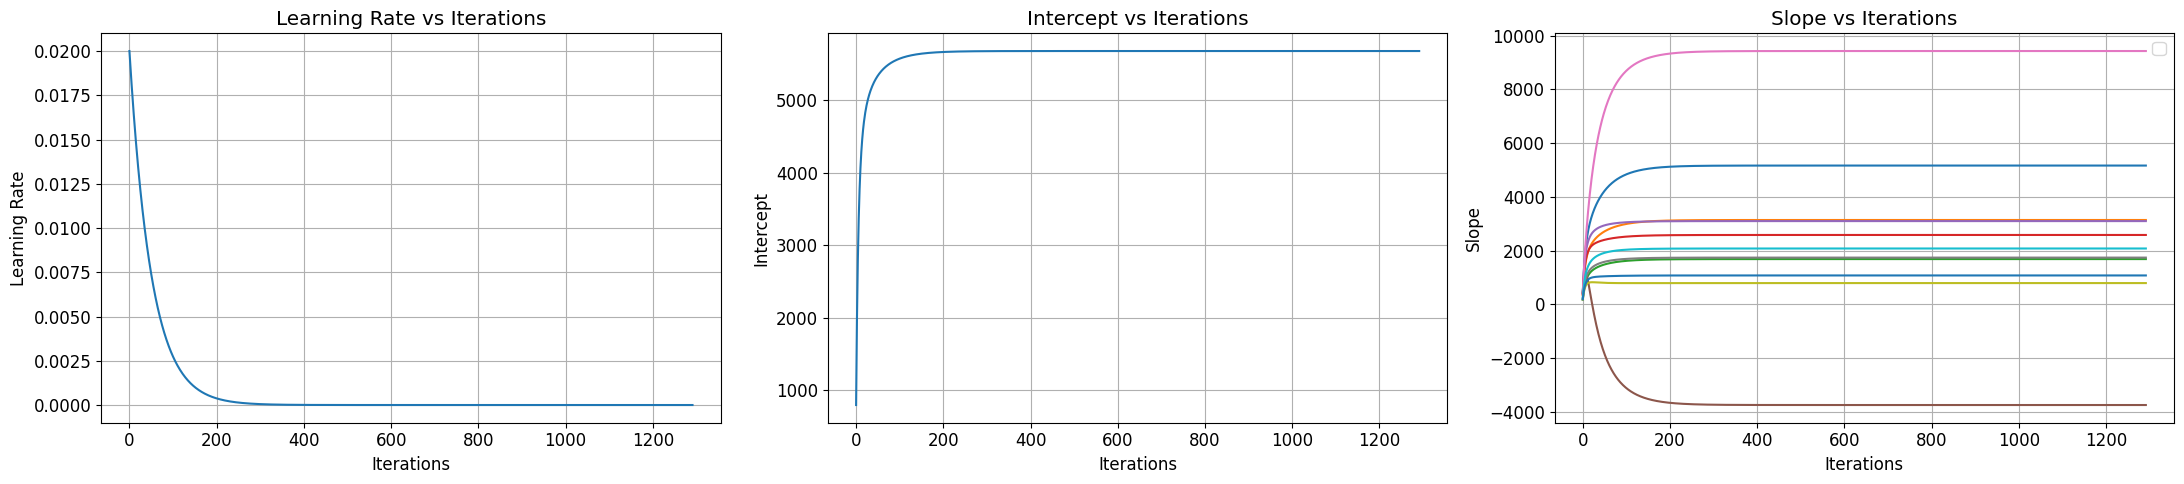

In [56]:
plt.figure(figsize=(22,5))

plt.subplot(1,3,1)
plt.plot(iterations, LR)
plt.title('Learning Rate vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Learning Rate')
plt.grid(True)


plt.subplot(1,3,2)
plt.plot(iterations, Intercept)
plt.title('Intercept vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Intercept')
plt.grid(True)


plt.subplot(1,3,3)
plt.plot(iterations, Slope)
plt.title('Slope vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Slope')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Making Predictions

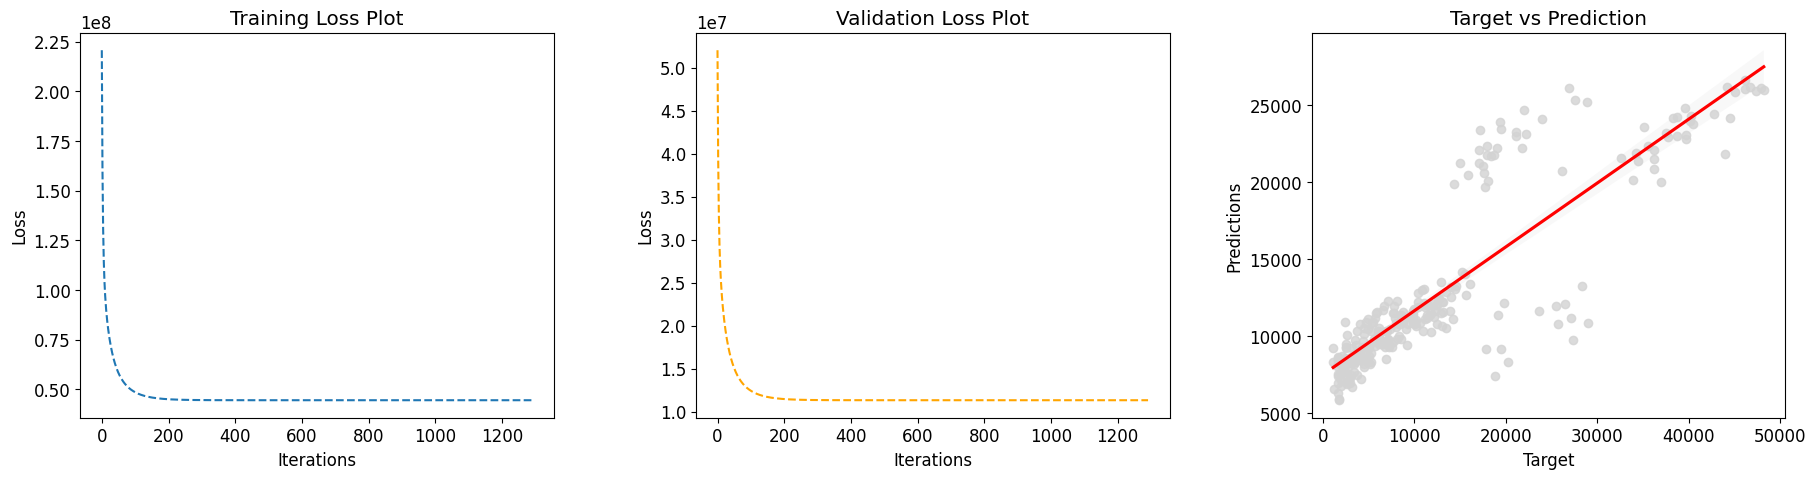

In [61]:
# Getting value of the cofficient and intercept of last itteration
cofficient = Slope[itteration]
intercept = Intercept[itteration]


# Predicting using the equation y = mx + b
y_pred = np.dot(scaled_X_test, cofficient) + intercept


# Creating dataframe to compare the predicted y and actual y
df = pd.DataFrame({'y_actual':y_test , 'y_pred':y_pred})

# Ploting the graphs
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(22,5))
fig.subplots_adjust(hspace=.2,wspace=.3)

# First plot (Training Loss plot)
ax1.plot(Trainingloss, linestyle='--')
ax1.set_title('Training Loss Plot')
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Loss')

# Second plot (Vlaidation Loss plot)
ax2.plot(Validationloss, linestyle='dashed', color='orange')
ax2.set_title('Validation Loss Plot')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Loss')

# Third plot (Target vs Prediction)
ax3 = sns.regplot(data=df,x=df['y_actual'], y=df['y_pred'], color='lightgray')
ax3.lines[0].set_color('red')
ax3.set_title('Target vs Prediction')
ax3.set_xlabel('Target')
ax3.set_ylabel('Predictions')

plt.show()